In [ ]:
!pip install openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.55.0
    Uninstalling openai-1.55.0:
      Successfully uninstalled openai-1.55.0


In [ ]:
import openai
# Set up OpenAI API key
openai.api_key = ''

* Transfer dataset samples to a gpt compatible format

In [ ]:
"Just a sample to understand the trasfer"

# import json

# # Sample input data
# data = [
#     {
#         "prev_utt": "of course",
#         "current_utt": "okay so the pots and pans are down here",
#         "elder_utt": "taking the pot out um and then you can help me fill it with water maybe",
#         "prev_hel_belief": {
#             "ot_belief": 1,
#             "l_belief": 0,
#             "o_belief": 0
#         },
#         "hel_belief": {
#             "ot_belief": 1,
#             "l_belief": 1,
#             "o_belief": 0
#         },
#         "prev_hel_action": 0,
#         "da": "Query-yn",
#         "hel_action": 5,
#         "prev_eld_da": "Instruct"
#     },
#     # Add more data entries here
# ]

# with open('dataset.jsonl', 'w') as f:
#     for entry in data:
#         prompt = (
#             f"eld_utt: {entry['elder_utt']}\n"
#             f"prev_utt: {entry['prev_utt']}\n"
#             f"prev_hel_belief: {json.dumps(entry['prev_hel_belief'])}\n"
#             f"eld_da: {entry['da']}\n\n"
#             f"hel_da: "
#         )
#         completion = f" {entry['prev_eld_da']}\nhel_action: {entry['hel_action']}"
#         json_line = json.dumps({"prompt": prompt, "completion": completion})
#         f.write(json_line + '\n')


In [ ]:
import json

# Load dataset
input_file_path = "/content/helper_data_final.json"
output_file_path = "/content/finetune_ready_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in prompt-completion format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Prepare the prompt
        prompt = (
            f"eld_utt: {entry['elder_utt']}\n"
            f"prev_utt: {entry['prev_utt']}\n"
            f"prev_hel_belief: {json.dumps(entry['prev_hel_belief'])}\n"
            f"eld_da: {entry['prev_eld_da']}\n\n"

        )

        # Prepare the completion
        completion = f" {entry['da']}\nhel_action: {entry['hel_action']}"

        # Write to output file
        json_line = json.dumps({"prompt": prompt, "completion": completion})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_dataset.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_dataset.jsonl


In [ ]:
import json

# Load dataset
input_file_path = "/content/helper_data_final.json"
output_file_path = "/content/updated_finetune_ready_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in prompt-completion format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Prepare the prompt
        prompt = (
            f"eld_utt: {entry['elder_utt']}\n"
            f"prev_utt: {entry['prev_utt']}\n"
            f"prev_hel_belief: {json.dumps(entry['prev_hel_belief'])}\n"
            f"eld_da: {entry['prev_eld_da']}\n\n"
            f"hel_da:"
        )

        # Prepare the completion
        completion = f" {entry['da']}\nhel_action: {entry['hel_action']}"

        # Write to output file
        json_line = json.dumps({"prompt": prompt, "completion": completion})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_dataset.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_dataset.jsonl


In [ ]:
import json
import numpy as np
import pandas as pd
import random

# Step 1: Load the transformed prompt-completion dataset
input_file_path = "/content/finetune_ready_dataset.jsonl"
training_output_path = "/content/pc_train_dataset.jsonl"
validation_output_path = "/content/pc_validation_dataset.jsonl"
test_output_path = "/content/pc_test_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = [json.loads(line) for line in infile]

# Extract labels for hel_da and hel_action to analyze class distribution
hel_da_classes = [entry['completion'].split('\n')[0].replace(' ', '').strip() for entry in data]
hel_action_classes = [int(entry['completion'].split('\n')[1].replace('hel_action: ', '').strip()) for entry in data]

# Step 2: Split the data to ensure class representation
def manual_balanced_split(data, hel_da_classes, hel_action_classes):
    train_indices = []
    val_indices = []
    test_indices = []

    # Split based on hel_action classes
    for cls in set(hel_action_classes):
        indices = [i for i, label in enumerate(hel_action_classes) if label == cls]
        random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Split based on hel_da classes
    for cls in set(hel_da_classes):
        indices = [i for i, label in enumerate(hel_da_classes) if label == cls]
        random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Remove duplicates and ensure indices are unique
    train_indices = list(set(train_indices))
    val_indices = list(set(val_indices))
    test_indices = list(set(test_indices))

    # Split the data
    train_data = [data[i] for i in train_indices]
    val_data = [data[i] for i in val_indices]
    test_data = [data[i] for i in test_indices]

    return train_data, val_data, test_data

train_data, validation_data, test_data = manual_balanced_split(data, hel_da_classes, hel_action_classes)

# Step 3: Extract labels for the training data
def extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes):
    train_hel_da_classes = []
    train_hel_action_classes = []

    for entry in train_data:
        index = data.index(entry)
        train_hel_da_classes.append(hel_da_classes[index])
        train_hel_action_classes.append(hel_action_classes[index])

    return train_hel_da_classes, train_hel_action_classes

train_hel_da_classes, train_hel_action_classes = extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes)

# Step 4: Upsample underrepresented classes in the training data
def upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes):
    # Convert training data to DataFrame-like structure for easy manipulation
    df_train = pd.DataFrame({
        'data': train_data,
        'hel_da': train_hel_da_classes,
        'hel_action': train_hel_action_classes
    })

    # Upsample hel_da classes with less than 3 samples
    for cls in set(train_hel_da_classes):
        class_data = df_train[df_train['hel_da'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Upsample hel_action classes with less than 3 samples
    for cls in set(train_hel_action_classes):
        class_data = df_train[df_train['hel_action'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Extract the upsampled training data
    upsampled_train_data = df_train['data'].tolist()

    return upsampled_train_data

balanced_train_data = upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes)

# Step 5: Write the training, validation, and test sets to separate files
# Write training set
with open(training_output_path, 'w') as train_file:
    for entry in balanced_train_data:
        json_line = json.dumps(entry)
        train_file.write(json_line + '\n')

# Write validation set
with open(validation_output_path, 'w') as val_file:
    for entry in validation_data:
        json_line = json.dumps(entry)
        val_file.write(json_line + '\n')

# Write test set
with open(test_output_path, 'w') as test_file:
    for entry in test_data:
        json_line = json.dumps(entry)
        test_file.write(json_line + '\n')

print("Dataset has been successfully split and upsampled into balanced training, validation, and test sets.")


Dataset has been successfully split and upsampled into balanced training, validation, and test sets.


## Role-based format (system, user, assistant)

In [ ]:
import json

In [ ]:
# Load dataset
input_file_path = "/content/augmented_helper_data.json"
output_file_path = "/content/aug_chat_format.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in role-based chat format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Create the messages list in role-based format
        messages = [
            {
                "role": "system",
                "content": "Helper is assisting an elder in a household task. The following context is provided to inform the response."
            },
            {
                "role": "user",
                "content": (
                    f"Elder's utterance: {entry['elder_utt']}\n"
                    f"Previous helper's utterance: {entry['prev_utt']}\n"
                    f"Previous helper belief: {json.dumps(entry['prev_hel_belief'])}\n"
                    f"Elder's dialogue act: {entry['prev_eld_da']}"
                )
            },
            {
                "role": "assistant",
                "content": (
                    f"Helper dialogue act: {entry['da']}\n"
                    f"Helper action: {entry['hel_action']}"
                )
            }
        ]

        # Write to output file in JSONL format
        json_line = json.dumps({"messages": messages})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl


In [ ]:
import json
import random
import numpy as np
import pandas as pd

# Step 1: Load the transformed role-based dataset
input_file_path = "/content/aug_chat_format.jsonl"
training_output_path = "/content/aug_train_dataset.jsonl"
validation_output_path = "/content/aug_validation_dataset.jsonl"
test_output_path = "/content/aug_test_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = [json.loads(line) for line in infile]

random.seed(0)
idxs = list(range(len(data)))
random.shuffle(idxs)
train_len = int(0.7*len(data))
valid_len = int(0.15*len(data))
train_idxs = idxs[:train_len]
valid_idxs = idxs[train_len:train_len+valid_len]
test_idxs = idxs[train_len+valid_len:]

train_data = [data[i] for i in train_idxs]
validation_data = [data[i] for i in valid_idxs]
test_data = [data[i] for i in test_idxs]

with open(training_output_path, 'w') as train_file:
    for entry in train_data:
        json_line = json.dumps(entry)
        train_file.write(json_line + '\n')

# Write validation set
with open(validation_output_path, 'w') as val_file:
    for entry in validation_data:
        json_line = json.dumps(entry)
        val_file.write(json_line + '\n')

# Write test set
with open(test_output_path, 'w') as test_file:
    for entry in test_data:
        json_line = json.dumps(entry)
        test_file.write(json_line + '\n')

In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score
random.seed(42)
# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:augmented-dataset:AXDjQTT1"

# Load the test dataset
test_file_path = "aug_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = model_output[1].replace("Helper action: ", "").strip()

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip()

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.40, F1 Score: 0.39
Helper Action (hel_action) - Accuracy: 0.36, F1 Score: 0.35


In [ ]:
import openai
import random
import json
from sklearn.metrics import accuracy_score, f1_score
random.seed(42)
# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:augmented-dataset:AXDjPeTL:ckpt-step-638"

# Load the test dataset
test_file_path = "aug_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = model_output[1].replace("Helper action: ", "").strip()

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip()

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.31, F1 Score: 0.27
Helper Action (hel_action) - Accuracy: 0.32, F1 Score: 0.30


In [ ]:
import openai
import random
import json
from sklearn.metrics import accuracy_score, f1_score
random.seed(42)
# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:augmented-dataset:AXDjQTT1"

# Load the test dataset
test_file_path = "aug_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = model_output[1].replace("Helper action: ", "").strip()

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip()

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.45, F1 Score: 0.43
Helper Action (hel_action) - Accuracy: 0.36, F1 Score: 0.34


In [ ]:
# Load dataset
input_file_path = "/content/helper_data_final.json"
output_file_path = "/content/finetune_chat_format.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in role-based chat format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Create the messages list in role-based format
        messages = [
            {
                "role": "system",
                "content": "Helper is assisting an elder in a household task. The following context is provided to inform the response."
            },
            {
                "role": "user",
                "content": (
                    f"Elder's utterance: {entry['elder_utt']}\n"
                    f"Previous helper's utterance: {entry['prev_utt']}\n"
                    f"Previous helper belief: {json.dumps(entry['prev_hel_belief'])}\n"
                    f"Elder's dialogue act: {entry['prev_eld_da']}"
                )
            },
            {
                "role": "assistant",
                "content": (
                    f"Helper dialogue act: {entry['da']}\n"
                    f"Helper action: {entry['hel_action']}"
                )
            }
        ]

        # Write to output file in JSONL format
        json_line = json.dumps({"messages": messages})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl


In [ ]:
import json

# Load dataset
input_file_path = "/content/helper_data_final_categorized.json"
output_file_path = "/content/updated_categorized_data.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in role-based chat format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Create the messages list in role-based format
        messages = [
            {
                "role": "system",
                "content": "Helper is assisting an elder in a household task by just giving helper's da and action labels back. The following context is provided to inform the response."
            },
            {
                "role": "user",
                "content": (
                    f"Elder's utterance: {entry['elder_utt']}\n"
                    f"Previous helper's utterance: {entry['prev_utt']}\n"
                    f"Previous helper belief: {json.dumps(entry['prev_hel_belief'])}\n"
                    f"Elder's dialogue act: {entry['prev_eld_da']}"
                )
            },
            {
                "role": "assistant",
                "content": (
                    f"Helper dialogue act: {entry['da']}\n"
                    f"Helper action: {entry['hel_action']}"
                )
            }
        ]

        # Write to output file in JSONL format
        json_line = json.dumps({"messages": messages})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl


In [ ]:
# from collections import Counter
# import numpy as np
# import pandas as pd

# # Load the transformed role-based dataset
# input_file_path = "/content/finetune_ready_chat_format.jsonl"
# training_output_path = "/content/chat_balanced_train_dataset.jsonl"
# validation_output_path = "/content/chat_balanced_validation_dataset.jsonl"
# test_output_path = "/content/chat_balanced_test_dataset.jsonl"

# # Load data from the input file
# with open(input_file_path, 'r') as infile:
#     data = [json.loads(line) for line in infile]

# # Extract the labels for hel_da and hel_action to analyze class distribution
# hel_da_classes = [entry['messages'][2]['content'].split('\n')[0].replace('Helper dialogue act: ', '').strip() for entry in data]
# hel_action_classes = [int(entry['messages'][2]['content'].split('\n')[1].replace('Helper action: ', '').strip()) for entry in data]

# # Count the occurrences of each class
# hel_da_counter = Counter(hel_da_classes)
# hel_action_counter = Counter(hel_action_classes)

# print("Class distribution for hel_da:", hel_da_counter)
# print("Class distribution for hel_action:", hel_action_counter)

# # Split and balance the data manually based on class representation
# def manual_balanced_split(data, hel_da_classes, hel_action_classes):
#     train_indices = []
#     val_indices = []
#     test_indices = []

#     # Split based on hel_action classes
#     for cls in set(hel_action_classes):
#         indices = [i for i, label in enumerate(hel_action_classes) if label == cls]
#         np.random.shuffle(indices)
#         if len(indices) >= 4:
#             train_indices.extend(indices[:2])
#             val_indices.append(indices[2])
#             test_indices.append(indices[3])
#         elif len(indices) == 3:
#             train_indices.extend(indices[:1])
#             val_indices.append(indices[1])
#             test_indices.append(indices[2])
#         elif len(indices) == 2:
#             train_indices.extend(indices[:1])
#             val_indices.append(indices[1])
#         elif len(indices) == 1:
#             train_indices.append(indices[0])

#     # Split based on hel_da classes
#     for cls in set(hel_da_classes):
#         indices = [i for i, label in enumerate(hel_da_classes) if label == cls]
#         np.random.shuffle(indices)
#         if len(indices) >= 4:
#             train_indices.extend(indices[:2])
#             val_indices.append(indices[2])
#             test_indices.append(indices[3])
#         elif len(indices) == 3:
#             train_indices.extend(indices[:1])
#             val_indices.append(indices[1])
#             test_indices.append(indices[2])
#         elif len(indices) == 2:
#             train_indices.extend(indices[:1])
#             val_indices.append(indices[1])
#         elif len(indices) == 1:
#             train_indices.append(indices[0])

#     # Remove duplicates and ensure indices are unique
#     train_indices = list(set(train_indices))
#     val_indices = list(set(val_indices))
#     test_indices = list(set(test_indices))

#     # Split the data
#     train_data = [data[i] for i in train_indices]
#     val_data = [data[i] for i in val_indices]
#     test_data = [data[i] for i in test_indices]

#     return train_data, val_data, test_data

# # Manually split the data
# train_data, validation_data, test_data = manual_balanced_split(data, hel_da_classes, hel_action_classes)

# # Function to upsample underrepresented classes in the training data
# def upsample_training_data(train_data, hel_da_classes, hel_action_classes):
#     # Convert training data to DataFrame-like structure for easy manipulation
#     df_train = pd.DataFrame({
#         'data': train_data,
#         'hel_da': hel_da_classes,
#         'hel_action': hel_action_classes
#     })

#     # Upsample hel_da classes with less than 3 samples
#     for cls in set(hel_da_classes):
#         class_data = df_train[df_train['hel_da'] == cls]
#         if len(class_data) < 3:
#             upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
#             df_train = pd.concat([df_train, upsampled_class_data], axis=0)

#     # Upsample hel_action classes with less than 3 samples
#     for cls in set(hel_action_classes):
#         class_data = df_train[df_train['hel_action'] == cls]
#         if len(class_data) < 3:
#             upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
#             df_train = pd.concat([df_train, upsampled_class_data], axis=0)

#     # Extract the upsampled training data
#     upsampled_train_data = df_train['data'].tolist()

#     return upsampled_train_data

# # Upsample the training data
# balanced_train_data = upsample_training_data(train_data, [hel_da_classes[i] for i in range(len(hel_da_classes)) if i in [entry for entry in train_data]],
#                                              [hel_action_classes[i] for i in range(len(hel_action_classes)) if i in [entry for entry in train_data]])

# # Write training set
# with open(training_output_path, 'w') as train_file:
#     for entry in balanced_train_data:
#         json_line = json.dumps(entry)
#         train_file.write(json_line + '\n')

# # Write validation set
# with open(validation_output_path, 'w') as val_file:
#     for entry in validation_data:
#         json_line = json.dumps(entry)
#         val_file.write(json_line + '\n')

# # Write test set
# with open(test_output_path, 'w') as test_file:
#     for entry in test_data:
#         json_line = json.dumps(entry)
#         test_file.write(json_line + '\n')

# print("Dataset has been successfully split and upsampled into balanced training, validation, and test sets.")


In [ ]:
import json
import random
import numpy as np
import pandas as pd

# Step 1: Load the transformed role-based dataset
input_file_path = "/content/updated_categorized_data.jsonl"
training_output_path = "/content/updated_categorized_train_dataset.jsonl"
validation_output_path = "/content/updated_categorized_validation_dataset.jsonl"
test_output_path = "/content/updated_categorized_test_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = [json.loads(line) for line in infile]

random.seed(0)
idxs = list(range(len(data)))
random.shuffle(idxs)
train_len = int(0.7*len(data))
valid_len = int(0.15*len(data))
train_idxs = idxs[:train_len]
valid_idxs = idxs[train_len:train_len+valid_len]
test_idxs = idxs[train_len+valid_len:]

train_data = [data[i] for i in train_idxs]
validation_data = [data[i] for i in valid_idxs]
test_data = [data[i] for i in test_idxs]

with open(training_output_path, 'w') as train_file:
    for entry in train_data:
        json_line = json.dumps(entry)
        train_file.write(json_line + '\n')

# Write validation set
with open(validation_output_path, 'w') as val_file:
    for entry in validation_data:
        json_line = json.dumps(entry)
        val_file.write(json_line + '\n')

# Write test set
with open(test_output_path, 'w') as test_file:
    for entry in test_data:
        json_line = json.dumps(entry)
        test_file.write(json_line + '\n')

In [ ]:

import openai
import random
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
# fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:updated-content-categorized:AWpguWGI"
fine_tuned_model = "ft:gpt-3.5-turbo-0125:personal:updated-content-categorized-gpt3:AWqD2ywU"

# Load the test dataset
test_file_path = "updated_categorized_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task by just giving helper's da and action labels back."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = model_output[1].replace("Helper action: ", "").strip()

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip()

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.31, F1 Score: 0.20
Helper Action (hel_action) - Accuracy: 0.17, F1 Score: 0.12


In [ ]:
import json
import random
import numpy as np
import pandas as pd

# Step 1: Load the transformed role-based dataset
input_file_path = "/content/finetune_categorized_data.jsonl"
training_output_path = "/content/categorized_train_dataset.jsonl"
validation_output_path = "/content/categorized_validation_dataset.jsonl"
test_output_path = "/content/categorized_test_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = [json.loads(line) for line in infile]

# Extract labels for hel_da and hel_action to analyze class distribution
hel_da_classes = [entry['messages'][2]['content'].split('\n')[0].replace('Helper dialogue act: ', '').strip() for entry in data]
hel_action_classes = [entry['messages'][2]['content'].split('\n')[1].replace('Helper action: ', '').strip() for entry in data]

# Step 2: Split the data to ensure class representation
def manual_balanced_split(data, hel_da_classes, hel_action_classes):
    train_indices = []
    val_indices = []
    test_indices = []

    # Split based on hel_action classes
    for cls in set(hel_action_classes):
        indices = [i for i, label in enumerate(hel_action_classes) if label == cls]
        np.random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Split based on hel_da classes
    for cls in set(hel_da_classes):
        indices = [i for i, label in enumerate(hel_da_classes) if label == cls]
        np.random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Remove duplicates and ensure indices are unique
    train_indices = list(set(train_indices))
    val_indices = list(set(val_indices))
    test_indices = list(set(test_indices))

    # Split the data
    train_data = [data[i] for i in train_indices]
    val_data = [data[i] for i in val_indices]
    test_data = [data[i] for i in test_indices]

    return train_data, val_data, test_data

train_data, validation_data, test_data = manual_balanced_split(data, hel_da_classes, hel_action_classes)

# Step 3: Extract labels for the training data
def extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes):
    train_hel_da_classes = []
    train_hel_action_classes = []

    for entry in train_data:
        index = data.index(entry)
        train_hel_da_classes.append(hel_da_classes[index])
        train_hel_action_classes.append(hel_action_classes[index])

    return train_hel_da_classes, train_hel_action_classes

train_hel_da_classes, train_hel_action_classes = extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes)

# Step 4: Upsample underrepresented classes in the training data
def upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes):
    # Convert training data to DataFrame-like structure for easy manipulation
    df_train = pd.DataFrame({
        'data': train_data,
        'hel_da': train_hel_da_classes,
        'hel_action': train_hel_action_classes
    })

    # Upsample hel_da classes with less than 3 samples
    for cls in set(train_hel_da_classes):
        class_data = df_train[df_train['hel_da'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Upsample hel_action classes with less than 3 samples
    for cls in set(train_hel_action_classes):
        class_data = df_train[df_train['hel_action'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Extract the upsampled training data
    upsampled_train_data = df_train['data'].tolist()

    return upsampled_train_data

balanced_train_data = upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes)

# Step 5: Write the training, validation, and test sets to separate files
# Write training set
with open(training_output_path, 'w') as train_file:
    for entry in balanced_train_data:
        json_line = json.dumps(entry)
        train_file.write(json_line + '\n')

# Write validation set
with open(validation_output_path, 'w') as val_file:
    for entry in validation_data:
        json_line = json.dumps(entry)
        val_file.write(json_line + '\n')

# Write test set
with open(test_output_path, 'w') as test_file:
    for entry in test_data:
        json_line = json.dumps(entry)
        test_file.write(json_line + '\n')

print("Dataset has been successfully split and upsampled into balanced training, validation, and test sets.")


Dataset has been successfully split and upsampled into balanced training, validation, and test sets.


In [ ]:
# openai files upload --purpose fine-tune --file chat_balanced_train_dataset.jsonl
# openai files upload --purpose fine-tune --file chat_balanced_validation_dataset.jsonl

In [ ]:
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.6/389.6 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.52.2
    Uninstalling openai-1.52.2:
      Successfully uninstalled openai-1.52.2


In [ ]:
# # new
# from openai import OpenAI
# import os

# client = OpenAI(
#   api_key=os.environ['OPENAI_API_KEY'],  # this is also the default, it can be omitted
# )

In [ ]:
!pip install openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.54.4
    Uninstalling openai-1.54.4:
      Successfully uninstalled openai-1.54.4


In [ ]:
# Upload the training dataset
train_file_response = openai.File.create(
    file=open("chat_balanced_train_dataset.jsonl", "rb"),
    purpose="fine-tune"
)

# Get the file ID from the response
train_file_id = train_file_response["id"]
print(f"Training file uploaded. File ID: {train_file_id}")

# Upload the validation dataset
validation_file_response = openai.File.create(
    file=open("chat_balanced_validation_dataset.jsonl", "rb"),
    purpose="fine-tune"
)

# Get the file ID from the response
validation_file_id = validation_file_response["id"]
print(f"Validation file uploaded. File ID: {validation_file_id}")


Training file uploaded. File ID: file-poMzfOEs9SSHCIpAoliKVk4j
Validation file uploaded. File ID: file-EDP5xtfpPvPlzbuAuXzlymAB


In [ ]:
# # Create the fine-tuning job
# fine_tune_response = openai.FineTune.create(
#     training_file=train_file_id,
#     validation_file=validation_file_id,
#     model="gpt-4o-2024-08-06"
# )

# fine_tune_id = fine_tune_response.get("id")
# print(f"Fine-tuning job created. Fine-tune ID: {fine_tune_id}")


# # from openai import OpenAI
# # client = OpenAI()

# # client.fine_tuning.jobs.create(
# #   training_file=train_file_id,
# #   validation_file=validation_file_id,
# #   model="gpt-4o-mini-2024-07-18"
# # )

In [ ]:
# import openai
# import json
# from sklearn.metrics import accuracy_score, f1_score

# # Fine-tuned model ID
# fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:thesis-trail1:APxKC2uy"

# # Load the test dataset
# test_file_path = "chat_balanced_test_dataset.jsonl"
# test_data = []
# with open(test_file_path, 'r') as file:
#     for line in file:
#         test_data.append(json.loads(line))

# # Initialize lists to store actual and predicted labels for evaluation
# actual_hel_da = []
# predicted_hel_da = []
# actual_hel_action = []
# predicted_hel_action = []

# # Iterate over each test sample
# for sample in test_data:
#     # Extract input fields
#     messages = sample["messages"]
#     eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
#     prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
#     prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
#     eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

#     # Construct the prompt for the fine-tuned model
#     prompt = (
#         f"eld_utt: {eld_utt}\n"
#         f"prev_utt: {prev_utt}\n"
#         f"prev_hel_belief: {prev_hel_belief}\n"
#         f"eld_da: {eld_da}\n\n"
#         f"hel_da:"
#     )

#     # Get model predictions
#     response = openai.ChatCompletion.create(
#         model=fine_tuned_model,
#         messages=chat_messages,
#         max_tokens=50,
#         temperature=0.7
#     )

#     # Extract predicted values
#     model_output = response['choices'][0]['text'].strip().split("\n")
#     predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
#     predicted_action = int(model_output[1].replace("Helper action: ", "").strip())

#     # Extract actual values
#     actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
#     actual_action = int(messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip())

#     # Store actual and predicted values
#     actual_hel_da.append(actual_da)
#     predicted_hel_da.append(predicted_da)
#     actual_hel_action.append(actual_action)
#     predicted_hel_action.append(predicted_action)

# # Evaluate performance using accuracy and F1-score for hel_da
# hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
# hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# # Evaluate performance using accuracy and F1-score for hel_action
# hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
# hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# # Print results
# print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
# print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:categorized-data:AWUcoioJ"

# Load the test dataset
test_file_path = "categorized_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = model_output[1].replace("Helper action: ", "").strip()

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip()

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.18, F1 Score: 0.18
Helper Action (hel_action) - Accuracy: 0.27, F1 Score: 0.16


In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:thesis-chat-trail1:ARgVvOEh"


# Load the test dataset
test_file_path = "chat_balanced_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = int(model_output[1].replace("Helper action: ", "").strip())

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = int(messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip())

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.25, F1 Score: 0.12
Helper Action (hel_action) - Accuracy: 0.42, F1 Score: 0.43


Helper Dialogue Act (hel_da) - Classification Report
              precision    recall  f1-score   support

                   0.33      1.00      0.50         3
 Acknowledge       0.00      0.00      0.00         1
       Check       0.00      0.00      0.00         1
     Query-w       0.00      0.00      0.00         3
    Query-yn       0.00      0.00      0.00         2
       State       0.00      0.00      0.00         0
     State-n       0.00      0.00      0.00         1
     State-y       0.00      0.00      0.00         1

    accuracy                           0.25        12
   macro avg       0.04      0.12      0.06        12
weighted avg       0.08      0.25      0.12        12



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

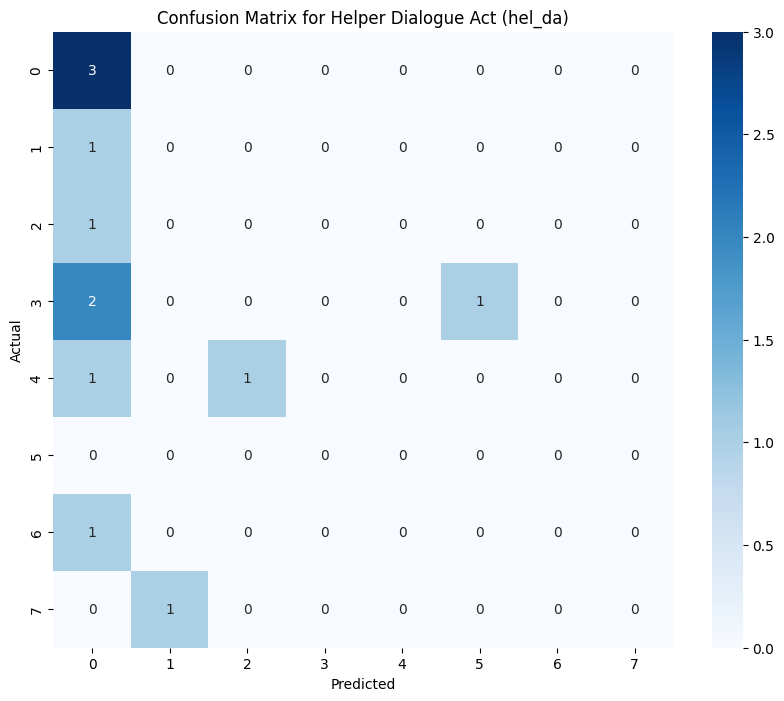

Helper Action (hel_action) - Classification Report
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.00      0.00      0.00         0
           2       0.33      0.50      0.40         2
           3       0.00      0.00      0.00         0
           4       1.00      1.00      1.00         1
           5       1.00      0.67      0.80         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2

    accuracy                           0.42        12
   macro avg       0.33      0.31      0.32        12
weighted avg       0.47      0.42      0.43        12



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

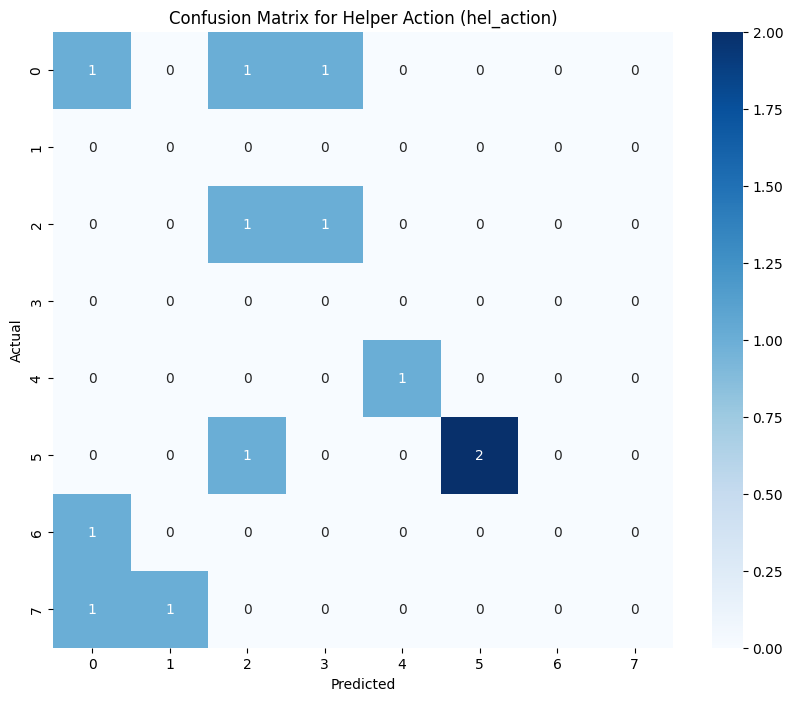

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix for hel_da
print("Helper Dialogue Act (hel_da) - Classification Report")
print(classification_report(actual_hel_da, predicted_hel_da))

# Plot Confusion Matrix for hel_da
conf_matrix_da = confusion_matrix(actual_hel_da, predicted_hel_da)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_da, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix for Helper Dialogue Act (hel_da)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for hel_action
print("Helper Action (hel_action) - Classification Report")
print(classification_report(actual_hel_action, predicted_hel_action))

# Plot Confusion Matrix for hel_action
conf_matrix_action = confusion_matrix(actual_hel_action, predicted_hel_action)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_action, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix for Helper Action (hel_action)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


* try GPT4o

In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-2024-08-06:personal:thesis-chat-trail2:ASV9UE1Y"

# Load the test dataset
test_file_path = "chat_balanced_test_dataset.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[0].replace("Helper dialogue act: ", "").strip()
    predicted_action = int(model_output[1].replace("Helper action: ", "").strip())

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[0].replace("Helper dialogue act: ", "").strip()
    actual_action = int(messages[2]["content"].split("\n")[1].replace("Helper action: ", "").strip())

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.08, F1 Score: 0.08
Helper Action (hel_action) - Accuracy: 0.25, F1 Score: 0.25


Helper Dialogue Act (hel_da) - Classification Report
              precision    recall  f1-score   support

                   0.00      0.00      0.00         3
 Acknowledge       0.00      0.00      0.00         1
       Check       0.00      0.00      0.00         1
     Query-w       0.00      0.00      0.00         3
    Query-yn       0.50      0.50      0.50         2
       State       0.00      0.00      0.00         0
     State-n       0.00      0.00      0.00         1
     State-y       0.00      0.00      0.00         1

    accuracy                           0.08        12
   macro avg       0.06      0.06      0.06        12
weighted avg       0.08      0.08      0.08        12



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

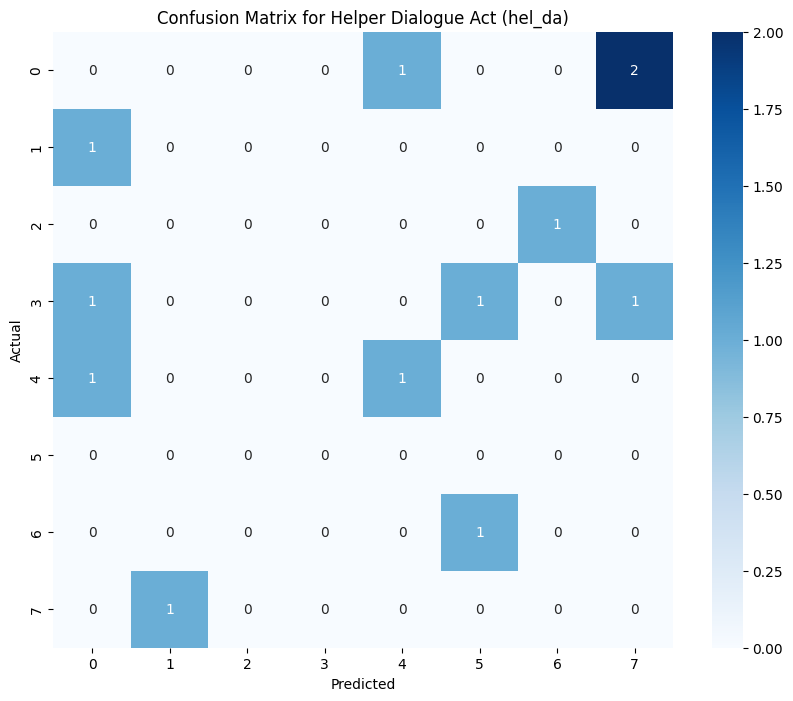

Helper Action (hel_action) - Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         0
           4       0.50      1.00      0.67         1
           5       0.33      0.33      0.33         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2

    accuracy                           0.25        12
   macro avg       0.26      0.26      0.24        12
weighted avg       0.29      0.25      0.25        12



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

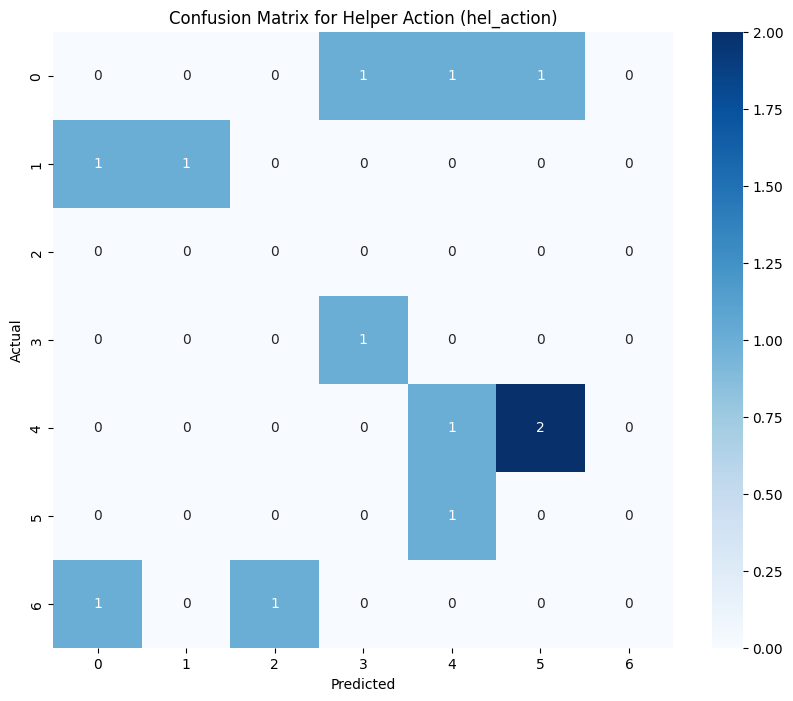

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix for hel_da
print("Helper Dialogue Act (hel_da) - Classification Report")
print(classification_report(actual_hel_da, predicted_hel_da))

# Plot Confusion Matrix for hel_da
conf_matrix_da = confusion_matrix(actual_hel_da, predicted_hel_da)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_da, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix for Helper Dialogue Act (hel_da)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for hel_action
print("Helper Action (hel_action) - Classification Report")
print(classification_report(actual_hel_action, predicted_hel_action))

# Plot Confusion Matrix for hel_action
conf_matrix_action = confusion_matrix(actual_hel_action, predicted_hel_action)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_action, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix for Helper Action (hel_action)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


* try new scenario

In [ ]:
import json
import random
import numpy as np
import pandas as pd

# Load dataset
input_file_path = "/content/updated_new_features.json"
output_file_path = "/content/updated_chat_format.jsonl"

with open(input_file_path, 'r') as infile:
    data = json.load(infile)

# Prepare data in role-based chat format
with open(output_file_path, 'w') as outfile:
    for entry in data:
        # Create the messages list in role-based format
        messages = [
            {
                "role": "system",
                "content": "Helper is assisting an elder in a household task. The following context is provided to inform the response."
            },
            {
                "role": "user",
                "content": (
                    f"Elder's utterance: {entry['elder_utt']}\n"
                    f"Previous helper's utterance: {entry['prev_hel_utt']}\n"
                    f"Previous helper belief: {json.dumps(entry['prev_hel_belief'])}\n"
                    f"Elder's dialogue act: {entry['eld_da']}\n"
                    f"Previous helper's dialogue act: {entry['prev_hel_da']}"
                )
            },
            {
                "role": "assistant",
                "content": (
                    f"Helper's utterance: {entry['current_utt']}\n"
                    f"Helper dialogue act: {entry['hel_da']}\n"
                    f"Helper action: {entry['hel_action']}"
                )
            }
        ]

        # Write to output file in JSONL format
        json_line = json.dumps({"messages": messages})
        outfile.write(json_line + '\n')

print("Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl")


Dataset has been successfully transformed and saved to finetune_ready_chat_format.jsonl


In [ ]:
import json
import random
import numpy as np
import pandas as pd

# Step 1: Load the transformed role-based dataset
input_file_path = "/content/updated_chat_format.jsonl"
training_output_path = "/content/updated_train_dataset.jsonl"
validation_output_path = "/content/updated_validation_dataset.jsonl"
test_output_path = "/content/updated_test_dataset.jsonl"

with open(input_file_path, 'r') as infile:
    data = [json.loads(line) for line in infile]

# Extract labels for hel_da and hel_action to analyze class distribution
hel_da_classes = [entry['messages'][2]['content'].split('\n')[1].replace('Helper dialogue act: ', '').strip() for entry in data]
hel_action_classes = [int(entry['messages'][2]['content'].split('\n')[2].replace('Helper action: ', '').strip()) for entry in data]

# Step 2: Split the data to ensure class representation
def manual_balanced_split(data, hel_da_classes, hel_action_classes):
    train_indices = []
    val_indices = []
    test_indices = []

    # Split based on hel_action classes
    for cls in set(hel_action_classes):
        indices = [i for i, label in enumerate(hel_action_classes) if label == cls]
        np.random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Split based on hel_da classes
    for cls in set(hel_da_classes):
        indices = [i for i, label in enumerate(hel_da_classes) if label == cls]
        np.random.shuffle(indices)
        if len(indices) >= 4:
            train_indices.extend(indices[:2])
            val_indices.append(indices[2])
            test_indices.append(indices[3])
        elif len(indices) == 3:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
            test_indices.append(indices[2])
        elif len(indices) == 2:
            train_indices.extend(indices[:1])
            val_indices.append(indices[1])
        elif len(indices) == 1:
            train_indices.append(indices[0])

    # Remove duplicates and ensure indices are unique
    train_indices = list(set(train_indices))
    val_indices = list(set(val_indices))
    test_indices = list(set(test_indices))

    # Split the data
    train_data = [data[i] for i in train_indices]
    val_data = [data[i] for i in val_indices]
    test_data = [data[i] for i in test_indices]

    return train_data, val_data, test_data

train_data, validation_data, test_data = manual_balanced_split(data, hel_da_classes, hel_action_classes)

# Step 3: Extract labels for the training data
def extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes):
    train_hel_da_classes = []
    train_hel_action_classes = []

    for entry in train_data:
        index = data.index(entry)
        train_hel_da_classes.append(hel_da_classes[index])
        train_hel_action_classes.append(hel_action_classes[index])

    return train_hel_da_classes, train_hel_action_classes

train_hel_da_classes, train_hel_action_classes = extract_labels_for_training_data(train_data, hel_da_classes, hel_action_classes)

# Step 4: Upsample underrepresented classes in the training data
def upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes):
    # Convert training data to DataFrame-like structure for easy manipulation
    df_train = pd.DataFrame({
        'data': train_data,
        'hel_da': train_hel_da_classes,
        'hel_action': train_hel_action_classes
    })

    # Upsample hel_da classes with less than 3 samples
    for cls in set(train_hel_da_classes):
        class_data = df_train[df_train['hel_da'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Upsample hel_action classes with less than 3 samples
    for cls in set(train_hel_action_classes):
        class_data = df_train[df_train['hel_action'] == cls]
        if len(class_data) < 3:
            upsampled_class_data = class_data.sample(n=3, replace=True, random_state=42)
            df_train = pd.concat([df_train, upsampled_class_data], axis=0)

    # Extract the upsampled training data
    upsampled_train_data = df_train['data'].tolist()

    return upsampled_train_data

balanced_train_data = upsample_training_data(train_data, train_hel_da_classes, train_hel_action_classes)

# Step 5: Write the training, validation, and test sets to separate files
# Write training set
with open(training_output_path, 'w') as train_file:
    for entry in balanced_train_data:
        json_line = json.dumps(entry)
        train_file.write(json_line + '\n')

# Write validation set
with open(validation_output_path, 'w') as val_file:
    for entry in validation_data:
        json_line = json.dumps(entry)
        val_file.write(json_line + '\n')

# Write test set
with open(test_output_path, 'w') as test_file:
    for entry in test_data:
        json_line = json.dumps(entry)
        test_file.write(json_line + '\n')

print("Dataset has been successfully split and upsampled into balanced training, validation, and test sets.")


Dataset has been successfully split and upsampled into balanced training, validation, and test sets.


In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:updated-add-features:AT8fDNS4"

# Load the test dataset
test_file_path = "updated_test_dataset2.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()
    prev_hel_da = messages[1]["content"].split("\n")[4].replace("Previous helper's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}\n"
            f"Previous helper's dialogue act: {prev_hel_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[1].replace("Helper dialogue act: ", "").strip()
    predicted_action = int(model_output[2].replace("Helper action: ", "").strip())

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[1].replace("Helper dialogue act: ", "").strip()
    actual_action = int(messages[2]["content"].split("\n")[2].replace("Helper action: ", "").strip())

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.17, F1 Score: 0.15
Helper Action (hel_action) - Accuracy: 0.17, F1 Score: 0.17


In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:updated-add-features:AT8fDNS4"

# Load the test dataset
test_file_path = "updated_test_dataset2.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()
    prev_hel_da = messages[1]["content"].split("\n")[4].replace("Previous helper's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}\n"
            f"Previous helper's dialogue act: {prev_hel_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=50,
        temperature=0.2
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[1].replace("Helper dialogue act: ", "").strip()
    predicted_action = int(model_output[2].replace("Helper action: ", "").strip())

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[1].replace("Helper dialogue act: ", "").strip()
    actual_action = int(messages[2]["content"].split("\n")[2].replace("Helper action: ", "").strip())

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Helper Dialogue Act (hel_da) - Accuracy: 0.08, F1 Score: 0.05
Helper Action (hel_action) - Accuracy: 0.08, F1 Score: 0.03


In [ ]:
import openai
import json
from sklearn.metrics import accuracy_score, f1_score

# Fine-tuned model ID
fine_tuned_model = "ft:gpt-4o-mini-2024-07-18:personal:updated-add-features:AT8fDNS4"

# Load the test dataset
test_file_path = "updated_test_dataset2.jsonl"
test_data = []
with open(test_file_path, 'r') as file:
    for line in file:
        test_data.append(json.loads(line))

# Initialize lists to store actual and predicted labels for evaluation
actual_hel_da = []
predicted_hel_da = []
actual_hel_action = []
predicted_hel_action = []

# Iterate over each test sample
for sample in test_data:
    # Extract input fields
    messages = sample["messages"]
    eld_utt = messages[1]["content"].split("\n")[0].replace("Elder's utterance: ", "").strip()
    prev_utt = messages[1]["content"].split("\n")[1].replace("Previous helper's utterance: ", "").strip()
    prev_hel_belief = json.loads(messages[1]["content"].split("\n")[2].replace("Previous helper belief: ", "").strip())
    eld_da = messages[1]["content"].split("\n")[3].replace("Elder's dialogue act: ", "").strip()
    prev_hel_da = messages[1]["content"].split("\n")[4].replace("Previous helper's dialogue act: ", "").strip()

    # Construct the messages for the fine-tuned chat model
    chat_messages = [
        {"role": "system", "content": "You are an assistant robot helping an elder in a household task."},
        {"role": "user", "content": (
            f"Elder's utterance: {eld_utt}\n"
            f"Previous helper's utterance: {prev_utt}\n"
            f"Previous helper belief: {prev_hel_belief}\n"
            f"Elder's dialogue act: {eld_da}\n"
            f"Previous helper's dialogue act: {prev_hel_da}"
        )}
    ]

    # Get model predictions using the chat endpoint
    response = openai.ChatCompletion.create(
        model=fine_tuned_model,
        messages=chat_messages,
        max_tokens=70,
        temperature=0.7
    )

    # Extract predicted values from the response
    model_output = response['choices'][0]['message']['content'].strip().split("\n")
    predicted_da = model_output[1].replace("Helper dialogue act: ", "").strip()
    predicted_action = int(model_output[2].replace("Helper action: ", "").strip())

    # Extract actual values
    actual_da = messages[2]["content"].split("\n")[1].replace("Helper dialogue act: ", "").strip()
    actual_action = int(messages[2]["content"].split("\n")[2].replace("Helper action: ", "").strip())

    # Store actual and predicted values
    actual_hel_da.append(actual_da)
    predicted_hel_da.append(predicted_da)
    actual_hel_action.append(actual_action)
    predicted_hel_action.append(predicted_action)

    print(f"Actual DA: {actual_da}, Predicted DA: {predicted_da}")
    print(f"Actual Action: {actual_action}, Predicted Action: {predicted_action}")

# Evaluate performance using accuracy and F1-score for hel_da
hel_da_accuracy = accuracy_score(actual_hel_da, predicted_hel_da)
hel_da_f1 = f1_score(actual_hel_da, predicted_hel_da, average='weighted')

# Evaluate performance using accuracy and F1-score for hel_action
hel_action_accuracy = accuracy_score(actual_hel_action, predicted_hel_action)
hel_action_f1 = f1_score(actual_hel_action, predicted_hel_action, average='weighted')

# Print results
print(f"Helper Dialogue Act (hel_da) - Accuracy: {hel_da_accuracy:.2f}, F1 Score: {hel_da_f1:.2f}")
print(f"Helper Action (hel_action) - Accuracy: {hel_action_accuracy:.2f}, F1 Score: {hel_action_f1:.2f}")


Actual DA: Query-yn, Predicted DA: 
Actual Action: 5, Predicted Action: 0
Actual DA: State-n, Predicted DA: State
Actual Action: 0, Predicted Action: 0
Actual DA: State-y, Predicted DA: 
Actual Action: 4, Predicted Action: 0
Actual DA: Check, Predicted DA: Query-w
Actual Action: 5, Predicted Action: 5
Actual DA: Query-w, Predicted DA: Query-w
Actual Action: 7, Predicted Action: 7
Actual DA: , Predicted DA: 
Actual Action: 5, Predicted Action: 0
Actual DA: Query-yn, Predicted DA: State
Actual Action: 6, Predicted Action: 0
Actual DA: Query-w, Predicted DA: State
Actual Action: 2, Predicted Action: 0
Actual DA: State-n, Predicted DA: 
Actual Action: 2, Predicted Action: 3
Actual DA: , Predicted DA: 
Actual Action: 0, Predicted Action: 3
Actual DA: Acknowledge, Predicted DA: Check
Actual Action: 4, Predicted Action: 5
Actual DA: Query-yn, Predicted DA: State
Actual Action: 5, Predicted Action: 0
Helper Dialogue Act (hel_da) - Accuracy: 0.25, F1 Score: 0.18
Helper Action (hel_action) - Acc

In [ ]:
print(predicted_action)

0


* changing all the numerical features to categorical

In [ ]:
import json

# Load the dataset
file_path = 'helper_data_final.json'
with open(file_path, 'r') as file:
    dataset = json.load(file)

# Define mappings for hel_action and beliefs
hel_action_mapping = {
    0: "No action",
    1: "Request OT",
    2: "Request L",
    3: "Verify OT",
    4: "Verify L",
    5: "Verify O",
    6: "Acknowledge",
    7: "Yes",
    8: "No"
}

belief_mapping = {
    0: "indeterminate",
    1: "match",
    2: "mismatch",
    3: "needs disambiguation"
}

# Process the dataset to replace numbers with categorical labels
for entry in dataset:
    # Update hel_action and prev_hel_action
    entry['hel_action'] = hel_action_mapping[entry['hel_action']]
    entry['prev_hel_action'] = hel_action_mapping[entry['prev_hel_action']]

    # Update beliefs in hel_belief and prev_hel_belief
    for belief_type in ['ot_belief', 'l_belief', 'o_belief']:
        entry['hel_belief'][belief_type] = belief_mapping[entry['hel_belief'][belief_type]]
        entry['prev_hel_belief'][belief_type] = belief_mapping[entry['prev_hel_belief'][belief_type]]

# Save the updated dataset
output_path = 'helper_data_final_categorized.json'
with open(output_path, 'w') as output_file:
    json.dump(dataset, output_file, indent=4)



* Data Augmentation

In [ ]:
!pip install textattack

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 30.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 40.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.5/776.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.7/769.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.3/143.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━